# Reviews Feature Engineering

This notebook transforms raw Airbnb review data into listing-level features that can later be merged with the listings dataset.

The objective is to summarize guest review activity for each property using aggregated indicators.

The main features created are:

- review_count
- avg_review_length
- latest_review_date
- avg_sentiment_score
- sentiment_label

These variables will later be merged with the engineered listings dataset for predictive modeling.

In [4]:
#setup
from pathlib import Path
import pandas as pd
import numpy as np
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk", "--quiet"])
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: /Users/andrerozza/Data Science for Business/airbnb-rome-analysis


In [5]:
reviews = pd.read_csv(
    "../data/reviews.csv.gz",
    compression="gzip"
)

## 1. Initial Exploration

Before creating new features, we inspect the structure of the review dataset and verify the available variables.

In [6]:
reviews.info()
reviews.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2477671 entries, 0 to 2477670
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   listing_id     int64 
 1   id             int64 
 2   date           object
 3   reviewer_id    int64 
 4   reviewer_name  object
 5   comments       object
dtypes: int64(3), object(3)
memory usage: 113.4+ MB


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,2737,24343517,2014-12-26,24333039,Raphaell,"This spot was in a great and nice area,walking..."
1,2737,24966779,2015-01-04,10493776,Ia,"Elif was really very helpful, while arranging ..."
2,2737,29770086,2015-04-12,29630601,Julia,"Elif's flat is spacious, clean, and had everyt..."
3,2737,30477570,2015-04-22,31215535,Sevil,I had a wonderful time staying with Elif and h...
4,2737,31659336,2015-05-08,1959813,Suzy,"Elif was a brilliant host, with an exceptional..."


In [7]:
reviews.isna().sum()

listing_id         0
id                 0
date               0
reviewer_id        0
reviewer_name      4
comments         164
dtype: int64

# 2. Data Preprocessing

In [8]:
before = reviews.shape[0]
reviews = reviews.dropna(subset=["comments"])
print(f"Dropped: {before - reviews.shape[0]} rows")
print(f"Remaining: {reviews.shape[0]} rows")

Dropped: 164 rows
Remaining: 2477507 rows


In [9]:
# Drop columns not needed for feature engineering
reviews.drop(columns=["id", "reviewer_id", "reviewer_name"], inplace=True)
print("Remaining columns:", reviews.columns.tolist())

Remaining columns: ['listing_id', 'date', 'comments']


In [10]:
# Verify no nulls remain in columns we use
print(reviews[["listing_id", "date", "comments"]].isna().sum())

listing_id    0
date          0
comments      0
dtype: int64


## 2.1.  Review Length Feature Engineering

Review length is measured as the number of words contained in each review comment.

Longer reviews may indicate higher guest engagement and provide a richer description of the listing experience.

We therefore create a review_length variable for every individual review.

In [11]:
reviews["comments"] = reviews["comments"].fillna("")
reviews["review_length"] = reviews["comments"].str.split().str.len()

In [12]:
reviews["review_length"].describe()

count    2.477507e+06
mean     4.528022e+01
std      4.198338e+01
min      1.000000e+00
25%      1.600000e+01
50%      3.400000e+01
75%      6.100000e+01
max      1.000000e+03
Name: review_length, dtype: float64


## 3. Sentiment Analysis

We use VADER (Valence Aware Dictionary and sEntiment Reasoner).
It scores each review with a compound value from -1 (very negative) to +1 (very positive).
No model training is required.

In [13]:
# sia = SentimentIntensityAnalyzer()

# reviews["sentiment_score"] = reviews["comments"].apply(
#     lambda text: sia.polarity_scores(text)["compound"]
# )

# reviews[["comments", "sentiment_score"]].sample(10000, random_state=42)

# reviews["sentiment_score"].describe()

#import swifter

#sia = SentimentIntensityAnalyzer()

#reviews["sentiment_score"] = reviews["comments"].swifter.apply(
#    lambda text: sia.polarity_scores(text)["compound"]

sia = SentimentIntensityAnalyzer()

reviews["comments"] = reviews["comments"].astype(str)

reviews["sentiment_score"] = reviews["comments"].apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

reviews["sentiment_score"].describe()


count    2.477507e+06
mean     5.079118e-01
std      5.015288e-01
min     -9.994000e-01
25%      0.000000e+00
50%      7.574000e-01
75%      9.428000e-01
max      9.998000e-01
Name: sentiment_score, dtype: float64

## 4. Listing-Level Review Aggregation

Machine learning models operate at the listing level rather than the individual review level.

Therefore, review information must be aggregated so that each listing is represented by a single observation.

### 4.1 Latest Review Date

The most recent review date is extracted for each listing.

This variable provides information about the recency of guest activity and may act as a proxy for listing demand.

In [35]:
reviews["date"] = pd.to_datetime(reviews["date"])

In [15]:
latest_review = (
    reviews.groupby("listing_id")["date"]
    .max()
    .reset_index(name="latest_review_date")
)

latest_review.head()

,listing_id,latest_review_date
0,2737,2015-05-08
1,11834,2026-06-07
2,12398,2025-08-01
3,19965,2026-06-13
4,20534,2022-11-22


### 4.1.2 Date Feature Engineering

Date variables cannot be directly used by machine learning algorithms.

We therefore transform review dates into numerical variables that capture review recency and temporal patterns.

## 5. Additional Review Recency Feature

The latest review date is transformed into a numerical variable representing the number of days since the most recent review.

Listings without reviews receive a large placeholder value (9999) to indicate very low review recency.

#### Latest Review Date Components

In [16]:
latest_review["latest_review_date"] = pd.to_datetime(
    latest_review["latest_review_date"],
    errors="coerce"
)

latest_review["latest_review_year"] = (
    latest_review["latest_review_date"].dt.year
)

latest_review["latest_review_month"] = (
    latest_review["latest_review_date"].dt.month
)

latest_review["latest_review_day"] = (
    latest_review["latest_review_date"].dt.day
)



In [17]:
reference_date = latest_review["latest_review_date"].max()

latest_review["days_since_latest_review"] = (
    reference_date - latest_review["latest_review_date"]
).dt.days

In [18]:
latest_review["days_since_latest_review"] = (
    latest_review["days_since_latest_review"]
    .fillna(9999)
)

since we already have the latest review date splitted and the feature for the day since last review, we can drop latest_review_date

In [19]:
latest_review = latest_review.drop(columns=["latest_review_date"])

In [20]:
latest_review.head()

,listing_id,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,2737,2015,5,8,4077
1,11834,2026,6,7,29
2,12398,2025,8,1,339
3,19965,2026,6,13,23
4,20534,2022,11,22,1322


### 4.2 Review Count and Average Review Length

For each listing we calculate:

- review_count
- avg_review_length

These variables summarize the volume and depth of guest feedback.

In [21]:
review_features = (
    reviews
    .groupby("listing_id")
    .agg(
        review_count=("comments", "count"),
        avg_review_length=("review_length", "mean"),
        avg_sentiment_score=("sentiment_score", "mean")
    )
    .reset_index()
)

review_features.head()

,listing_id,review_count,avg_review_length,avg_sentiment_score
0,2737,5,51.800000,0.956560
1,11834,302,74.165563,0.849785
2,12398,85,84.658824,0.719140
3,19965,195,44.953846,0.463973
4,20534,50,60.200000,0.730592


### 4.3 Sentiment Label

Categorical version of avg_sentiment_score using VADER's recommended thresholds:
>= 0.05  → positive
<= -0.05 → negative
between  → neutral

In [22]:
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

review_features["sentiment_label"] = review_features["avg_sentiment_score"].apply(label_sentiment)

review_features["sentiment_label"].value_counts()

sentiment_label
positive    30519
neutral      1623
negative      684
Name: count, dtype: int64

### 4.4 Merge Aggregated Features

All review-based features are combined into a single listing-level dataset.

Each row now corresponds to one Airbnb listing.

In [23]:
review_features = review_features.merge(
    latest_review,
    on="listing_id",
    how="left"
)

In [24]:
review_features.head()

,listing_id,review_count,avg_review_length,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,2737,5,51.800000,0.956560,positive,2015,5,8,4077
1,11834,302,74.165563,0.849785,positive,2026,6,7,29
2,12398,85,84.658824,0.719140,positive,2025,8,1,339
3,19965,195,44.953846,0.463973,positive,2026,6,13,23
4,20534,50,60.200000,0.730592,positive,2022,11,22,1322


## 5. Quality Checks

Before exporting the dataset, we verify:

- dataset dimensions
- missing values
- feature completeness

In [25]:
print(review_features.shape)

review_features.isnull().sum()

(32826, 9)


listing_id                  0
review_count                0
avg_review_length           0
avg_sentiment_score         0
sentiment_label             0
latest_review_year          0
latest_review_month         0
latest_review_day           0
days_since_latest_review    0
dtype: int64

## 6. Descriptive Statistics
Summary statistics are generated to understand the distribution of the engineered review features.

In [26]:
review_features["review_count"].describe()

count    32826.000000
mean        75.473923
std        110.381679
min          1.000000
25%          8.000000
50%         33.000000
75%         94.000000
max       3080.000000
Name: review_count, dtype: float64

In [27]:
review_features["avg_review_length"].describe()

count    32826.000000
mean        43.386356
std         17.756383
min          1.000000
25%         33.951210
50%         42.157072
75%         50.844651
max        300.000000
Name: avg_review_length, dtype: float64

In [28]:
review_features["avg_sentiment_score"].describe()

count    32826.000000
mean         0.419177
std          0.237327
min         -0.991400
25%          0.284020
50%          0.426413
75%          0.574185
max          0.996600
Name: avg_sentiment_score, dtype: float64

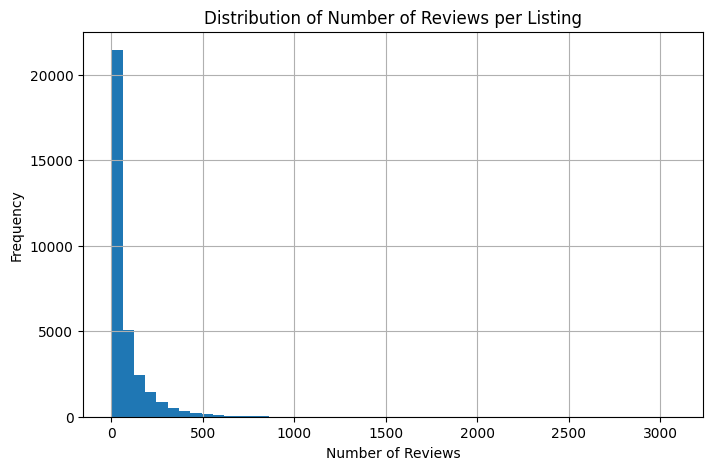

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
review_features["review_count"].hist(bins=50)
plt.title("Distribution of Number of Reviews per Listing")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

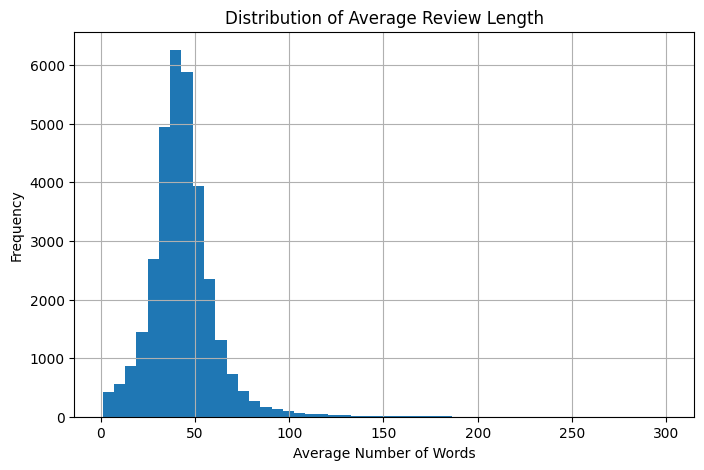

In [30]:
plt.figure(figsize=(8,5))
review_features["avg_review_length"].hist(bins=50)
plt.title("Distribution of Average Review Length")
plt.xlabel("Average Number of Words")
plt.ylabel("Frequency")
plt.show()

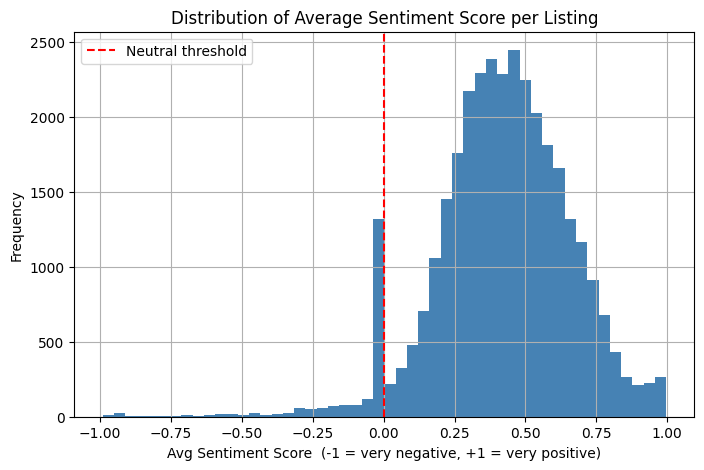

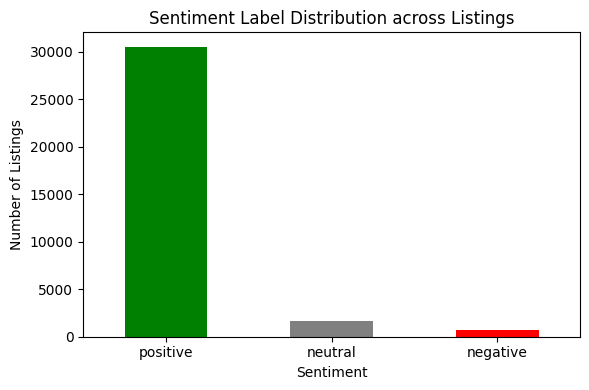

In [31]:
plt.figure(figsize=(8, 5))
review_features["avg_sentiment_score"].hist(bins=50, color="steelblue")
plt.title("Distribution of Average Sentiment Score per Listing")
plt.xlabel("Avg Sentiment Score  (-1 = very negative, +1 = very positive)")
plt.ylabel("Frequency")
plt.axvline(0, color="red", linestyle="--", label="Neutral threshold")
plt.legend()
plt.show()

# %%
plt.figure(figsize=(6, 4))
review_features["sentiment_label"].value_counts().plot(kind="bar", color=["green", "gray", "red"])
plt.title("Sentiment Label Distribution across Listings")
plt.xlabel("Sentiment")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Export Processed Dataset

The engineered review features are exported and will later be merged with the listings feature dataset created in Notebook 02.

In [32]:
# summary of what the dataset has
review_features.head()

,listing_id,review_count,avg_review_length,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,2737,5,51.800000,0.956560,positive,2015,5,8,4077
1,11834,302,74.165563,0.849785,positive,2026,6,7,29
2,12398,85,84.658824,0.719140,positive,2025,8,1,339
3,19965,195,44.953846,0.463973,positive,2026,6,13,23
4,20534,50,60.200000,0.730592,positive,2022,11,22,1322


In [33]:
review_features.isna().sum()

listing_id                  0
review_count                0
avg_review_length           0
avg_sentiment_score         0
sentiment_label             0
latest_review_year          0
latest_review_month         0
latest_review_day           0
days_since_latest_review    0
dtype: int64

In [34]:
review_features.to_csv(
    "../data/review_features.csv",
    index=False
)

print("review_features.csv saved")

review_features.csv saved
